# Lab 19 — Embeddings, Retrieval, and RAG

**Book:** *The Mathematics of Natural Language Processing*  
**Chapter:** 19 — Embeddings, Retrieval, and RAG  
**Repository:** [Book-MathNLP](https://github.com/wanghemath/Book-MathNLP)

[Open this lab in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-19-embeddings-retrieval-rag.ipynb)

## Independent-study purpose

This lab is designed for students to work through independently.  It includes the mathematical background before each programming section, small examples that can be inspected by hand, and exercises that gradually move from computation to interpretation.

In this lab, you will build a small retrieval-augmented generation pipeline from scratch.  The word "generation" here is implemented by a transparent rule-based answer builder rather than by calling a large language model.  This is intentional: the goal is to understand the retrieval mathematics before using a black-box generator.

## Learning goals

After completing this lab, you should be able to:

1. represent documents and queries as vectors;
2. distinguish **sparse lexical retrieval** from **dense semantic retrieval**;
3. compute cosine similarity and retrieve top-$k$ documents by matrix multiplication;
4. combine sparse and dense scores in a **hybrid retriever**;
5. explain why chunking changes a RAG system;
6. compute retrieval metrics such as precision@$k$, recall@$k$, MRR, and nDCG;
7. build a small transparent RAG-style pipeline with citations;
8. diagnose retrieval, ranking, and context-construction failures.

## 1. Mathematical background: retrieval as geometry

A retrieval system starts with a collection of text units

$$
C = \{c_1,c_2,\ldots,c_n\}.
$$

A query is another text unit $q$.  An embedding model maps text into vectors:

$$
f: \text{text} \to R^m.
$$

If $x_i = f(c_i)$ and $z = f(q)$, a common retrieval score is cosine similarity:

$$
\operatorname{cos}(z,x_i)
= \frac{z^T x_i}{\|z\|_2\|x_i\|_2}.
$$

When all document vectors are normalized, retrieval can be written as a matrix multiplication problem.  Let $X$ be the document matrix whose rows are normalized document vectors.  Let $z$ be the normalized query vector.  Then all scores are computed at once by

$$
s = Xz.
$$

The top-$k$ retrieved documents are the indices of the largest entries of $s$.

## 2. Setup

This lab uses only standard scientific Python tools available in Google Colab: `numpy`, `pandas`, and `matplotlib`.  We avoid internet downloads so the lab is reproducible.

In [1]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(7243)

## 3. A small document collection

We use a toy collection inspired by an academic NLP setting.  Each item has an ID, a title, and a short text.  In a real RAG system, these might be paragraphs from a syllabus, advising policy, textbook, documentation page, or research article.

In [2]:
documents = [
    {
        "id": "D1",
        "title": "MS Applied Mathematics advising",
        "text": "Students in the MS Applied Mathematics program should plan courses with an academic advisor. Core courses include applied linear algebra, probability, stochastic processes, optimization, and machine learning."
    },
    {
        "id": "D2",
        "title": "Transfer credit policy",
        "text": "Transfer credits require official syllabi, transcript evidence, and approval by the graduate program director. Courses must be graduate level and substantially similar to the required curriculum."
    },
    {
        "id": "D3",
        "title": "Mathematical foundations of AI",
        "text": "Modern artificial intelligence relies on linear algebra, probability, optimization, numerical computation, statistical learning theory, and high-dimensional geometry."
    },
    {
        "id": "D4",
        "title": "Naive Bayes classifier",
        "text": "The Naive Bayes text classifier uses Bayes rule with conditional independence assumptions. It estimates class priors and token likelihoods from labeled documents."
    },
    {
        "id": "D5",
        "title": "Word embeddings",
        "text": "Word embeddings represent tokens as vectors. Similar words tend to have nearby vectors, and vector arithmetic can reveal semantic directions."
    },
    {
        "id": "D6",
        "title": "Transformer attention",
        "text": "Transformers use self-attention to compute contextual token representations. Queries, keys, and values define weighted combinations of information across a sequence."
    },
    {
        "id": "D7",
        "title": "Retrieval augmented generation",
        "text": "RAG systems retrieve relevant chunks from an external collection and pass them as context to a language model. Retrieval helps answer questions about documents not memorized during training."
    },
    {
        "id": "D8",
        "title": "Campus tutoring and support",
        "text": "Students can use tutoring, office hours, peer study groups, library services, and writing support to improve learning and academic success."
    },
    {
        "id": "D9",
        "title": "Evaluation of retrieval",
        "text": "Retrieval systems are evaluated using precision at k, recall at k, mean reciprocal rank, discounted cumulative gain, and human audits of evidence quality."
    },
    {
        "id": "D10",
        "title": "Information theory for language",
        "text": "Entropy, cross entropy, KL divergence, and perplexity measure uncertainty and mismatch between probability distributions over tokens."
    },
]

pd.DataFrame(documents)[["id", "title", "text"]]

,id,title,text
0,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
1,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."
2,D3,Mathematical foundations of AI,Modern artificial intelligence relies on linea...
3,D4,Naive Bayes classifier,The Naive Bayes text classifier uses Bayes rul...
4,D5,Word embeddings,Word embeddings represent tokens as vectors. S...
5,D6,Transformer attention,Transformers use self-attention to compute con...
6,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
7,D8,Campus tutoring and support,"Students can use tutoring, office hours, peer ..."
8,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
9,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."


## 4. Basic text preprocessing

For retrieval, preprocessing choices matter.  We will use a simple tokenizer:

1. lowercase the text;
2. keep alphabetic tokens;
3. remove a small list of stop words.

This is not the only correct choice.  The point is to make the choices explicit so we can audit them mathematically.

In [3]:
stop_words = {
    "the", "a", "an", "and", "or", "to", "of", "in", "on", "for", "with",
    "from", "as", "by", "are", "is", "be", "it", "them", "during", "at", "use"
}

def tokenize(text, remove_stop=True):
    tokens = re.findall(r"[a-z]+", text.lower())
    if remove_stop:
        tokens = [t for t in tokens if t not in stop_words]
    return tokens

for doc in documents[:3]:
    print(doc["id"], tokenize(doc["text"])[:15])

D1 ['students', 'ms', 'applied', 'mathematics', 'program', 'should', 'plan', 'courses', 'academic', 'advisor', 'core', 'courses', 'include', 'applied', 'linear']
D2 ['transfer', 'credits', 'require', 'official', 'syllabi', 'transcript', 'evidence', 'approval', 'graduate', 'program', 'director', 'courses', 'must', 'graduate', 'level']
D3 ['modern', 'artificial', 'intelligence', 'relies', 'linear', 'algebra', 'probability', 'optimization', 'numerical', 'computation', 'statistical', 'learning', 'theory', 'high', 'dimensional']


## 5. Sparse retrieval with TF-IDF from scratch

A sparse retriever uses exact or near-exact token overlap.  The standard document-term matrix has entries such as term counts or TF-IDF weights.

Let $N$ be the number of documents and let $df_j$ be the number of documents containing term $j$.  A common smoothed inverse document frequency is

$$
idf_j = \log\left(\frac{1+N}{1+df_j}\right) + 1.
$$

The TF-IDF vector of a document gives more weight to terms that are frequent in that document but less common across the whole collection.

In [4]:
def build_vocabulary(texts):
    vocab = sorted(set(t for text in texts for t in tokenize(text)))
    return {term: j for j, term in enumerate(vocab)}

def count_matrix(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=float)
    for i, text in enumerate(texts):
        counts = Counter(tokenize(text))
        for term, count in counts.items():
            if term in vocab:
                X[i, vocab[term]] = count
    return X

def tfidf_matrix(texts, vocab):
    counts = count_matrix(texts, vocab)
    N = counts.shape[0]
    df = (counts > 0).sum(axis=0)
    idf = np.log((1 + N) / (1 + df)) + 1
    tf = counts / np.maximum(counts.sum(axis=1, keepdims=True), 1)
    return tf * idf, idf

def l2_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

texts = [d["title"] + " " + d["text"] for d in documents]
vocab = build_vocabulary(texts)
X_tfidf, idf = tfidf_matrix(texts, vocab)
X_tfidf_norm = l2_normalize(X_tfidf)

print("Number of documents:", len(documents))
print("Vocabulary size:", len(vocab))
print("Example vocabulary terms:", list(vocab)[:20])

Number of documents: 10
Vocabulary size: 160
Example vocabulary terms: ['about', 'academic', 'across', 'advising', 'advisor', 'ai', 'algebra', 'answer', 'applied', 'approval', 'arithmetic', 'artificial', 'assumptions', 'attention', 'audits', 'augmented', 'bayes', 'between', 'campus', 'can']


In [5]:
def vectorize_query_tfidf(query, vocab, idf):
    counts = np.zeros(len(vocab), dtype=float)
    q_counts = Counter(tokenize(query))
    for term, count in q_counts.items():
        if term in vocab:
            counts[vocab[term]] = count
    tf = counts / max(counts.sum(), 1)
    return tf * idf

def top_k(scores, k=5):
    return np.argsort(scores)[::-1][:k]

def show_results(query, scores, k=5, label="retriever"):
    rows = []
    for rank, idx in enumerate(top_k(scores, k), start=1):
        rows.append({
            "rank": rank,
            "score": float(scores[idx]),
            "id": documents[idx]["id"],
            "title": documents[idx]["title"],
            "text": documents[idx]["text"][:110] + "..."
        })
    print(f"Query: {query}")
    print(f"Retriever: {label}")
    return pd.DataFrame(rows)

query = "What math courses support artificial intelligence and machine learning?"
q_tfidf = vectorize_query_tfidf(query, vocab, idf)
sparse_scores = X_tfidf_norm @ (q_tfidf / max(np.linalg.norm(q_tfidf), 1e-12))
show_results(query, sparse_scores, k=5, label="TF-IDF cosine")

Query: What math courses support artificial intelligence and machine learning?
Retriever: TF-IDF cosine


,rank,score,id,title,text
0,1,0.269616,D3,Mathematical foundations of AI,Modern artificial intelligence relies on linea...
1,2,0.238500,D8,Campus tutoring and support,"Students can use tutoring, office hours, peer ..."
2,3,0.222791,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
3,4,0.063062,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."
4,5,0.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...


### Exercise 1

Try at least two new queries.  For each query, decide whether TF-IDF behaves well or badly.  A good retrieval result should not merely share words; it should answer the information need.

In [6]:
# Try your own queries here.
student_queries = [
    "How do I get transfer credit approved?",
    "How can retrieval help answer questions about new documents?",
]

for q in student_queries:
    q_vec = vectorize_query_tfidf(q, vocab, idf)
    q_norm = q_vec / max(np.linalg.norm(q_vec), 1e-12)
    scores = X_tfidf_norm @ q_norm
    display(show_results(q, scores, k=3, label="TF-IDF cosine"))

Query: How do I get transfer credit approved?
Retriever: TF-IDF cosine


,rank,score,id,title,text
0,1,0.425195,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."
1,2,0.000000,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."
2,3,0.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...


Query: How can retrieval help answer questions about new documents?
Retriever: TF-IDF cosine


,rank,score,id,title,text
0,1,0.473417,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
1,2,0.134524,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
2,3,0.068207,D8,Campus tutoring and support,"Students can use tutoring, office hours, peer ..."


## 6. Dense retrieval with toy semantic embeddings

Sparse retrieval can fail when the query and relevant document use different words.  Dense retrieval tries to represent semantic meaning in a continuous vector space.

In a production system, dense vectors come from a trained embedding model.  In this independent-study lab, we will build a transparent toy embedding model using interpretable semantic axes:

1. advising and administration;
2. probability and mathematical theory;
3. machine learning and AI;
4. neural sequence models;
5. retrieval and evaluation;
6. student support.

A document embedding is the average of its token embeddings.  This is simple, but it demonstrates the geometry of dense retrieval.

In [7]:
semantic_axes = [
    "advising_admin",
    "probability_math",
    "ml_ai",
    "sequence_models",
    "retrieval_evaluation",
    "student_support",
]

lexicon = {
    # advising and administration
    "student": [1,0,0,0,0,1], "students": [1,0,0,0,0,1], "advisor": [1,0,0,0,0,0],
    "advising": [1,0,0,0,0,0], "approval": [1,0,0,0,0,0], "approved": [1,0,0,0,0,0],
    "credit": [1,0,0,0,0,0], "credits": [1,0,0,0,0,0], "transfer": [1,0,0,0,0,0],
    "program": [1,0.4,0,0,0,0], "curriculum": [1,0.6,0,0,0,0],
    # math and probability
    "math": [0,1,0,0,0,0], "mathematical": [0,1,0.4,0,0,0], "linear": [0,1,0.4,0,0,0],
    "algebra": [0,1,0.4,0,0,0], "probability": [0,1,0.3,0,0,0], "stochastic": [0,1,0.2,0,0,0],
    "optimization": [0,1,0.5,0,0,0], "entropy": [0,1,0,0,0.3,0], "perplexity": [0,0.8,0,0,0.4,0],
    "kl": [0,1,0,0,0.2,0], "divergence": [0,1,0,0,0.2,0], "geometry": [0,1,0.4,0,0.3,0],
    # AI and ML
    "ai": [0,0.3,1,0,0,0], "artificial": [0,0.2,1,0,0,0], "intelligence": [0,0.2,1,0,0,0],
    "machine": [0,0.2,1,0,0,0], "learning": [0,0.2,1,0,0,0.4], "classifier": [0,0.5,1,0,0,0],
    "bayes": [0,0.8,0.6,0,0,0], "statistical": [0,0.8,0.6,0,0,0],
    # sequence / transformer
    "transformer": [0,0.2,0.8,1,0,0], "transformers": [0,0.2,0.8,1,0,0], "attention": [0,0.2,0.7,1,0,0],
    "token": [0,0.2,0.4,0.7,0,0], "tokens": [0,0.2,0.4,0.7,0,0], "sequence": [0,0.2,0.4,1,0,0],
    "contextual": [0,0.1,0.5,1,0.2,0],
    # retrieval and evaluation
    "retrieval": [0,0,0.5,0,1,0], "retrieve": [0,0,0.4,0,1,0], "rag": [0,0,0.6,0,1,0],
    "chunks": [0,0,0.2,0,1,0], "chunk": [0,0,0.2,0,1,0], "context": [0,0,0.3,0.2,1,0],
    "evaluated": [0,0.2,0,0,1,0], "evaluation": [0,0.2,0,0,1,0], "precision": [0,0.4,0,0,1,0],
    "recall": [0,0.4,0,0,1,0], "rank": [0,0.2,0,0,1,0], "evidence": [0,0.2,0,0,1,0],
    "documents": [0,0,0,0,1,0], "document": [0,0,0,0,1,0],
    # support
    "tutoring": [0,0,0,0,0,1], "office": [0.3,0,0,0,0,1], "hours": [0.3,0,0,0,0,1],
    "library": [0,0,0,0,0,1], "writing": [0,0,0,0,0,1], "support": [0,0,0,0,0,1],
    "success": [0,0,0,0,0,1]
}

# Convert to numpy arrays.
lexicon = {k: np.array(v, dtype=float) for k, v in lexicon.items()}

# Small deterministic fallback for unknown words.
def fallback_vector(token):
    # A tiny vector based on character counts, only to avoid zero vectors for every unknown term.
    vowels = sum(ch in "aeiou" for ch in token)
    length = len(token)
    return 0.03 * np.array([
        length % 3,
        vowels % 4,
        token.count("i") + token.count("a"),
        token.count("t"),
        token.count("r"),
        token.count("s"),
    ], dtype=float)

def token_embedding(token):
    return lexicon.get(token, fallback_vector(token))

def text_embedding(text):
    tokens = tokenize(text)
    if not tokens:
        return np.zeros(len(semantic_axes))
    return np.mean([token_embedding(t) for t in tokens], axis=0)

X_dense = np.vstack([text_embedding(t) for t in texts])
X_dense_norm = l2_normalize(X_dense)

pd.DataFrame(X_dense, columns=semantic_axes, index=[d["id"] for d in documents])

,advising_admin,probability_math,ml_ai,sequence_models,retrieval_evaluation,student_support
D1,0.174615,0.253077,0.165769,0.004615,0.004615,0.067692
D2,0.344091,0.079091,0.028636,0.010909,0.061818,0.010909
D3,0.011053,0.422632,0.385789,0.006316,0.022105,0.025789
D4,0.024000,0.210000,0.235500,0.044000,0.054500,0.016500
D5,0.023684,0.062632,0.046316,0.051053,0.020526,0.014211
D6,0.013333,0.105556,0.260556,0.382222,0.019444,0.015000
D7,0.023478,0.027391,0.129565,0.021739,0.312174,0.011739
D8,0.096842,0.032632,0.063684,0.001579,0.006316,0.555263
D9,0.019500,0.104000,0.071000,0.007500,0.403000,0.009000
D10,0.024706,0.374118,0.064118,0.055294,0.094706,0.010588


In [8]:
def dense_scores_for_query(query):
    q = text_embedding(query)
    q = q / max(np.linalg.norm(q), 1e-12)
    return X_dense_norm @ q

query = "How can a system answer questions using retrieved evidence?"
dense_scores = dense_scores_for_query(query)
show_results(query, dense_scores, k=5, label="toy dense cosine")

Query: How can a system answer questions using retrieved evidence?
Retriever: toy dense cosine


,rank,score,id,title,text
0,1,0.983485,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
1,2,0.925934,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
2,3,0.581329,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."
3,4,0.536786,D5,Word embeddings,Word embeddings represent tokens as vectors. S...
4,5,0.488770,D4,Naive Bayes classifier,The Naive Bayes text classifier uses Bayes rul...


### Visualization: dense semantic axes

Because our toy dense embeddings have interpretable coordinates, we can plot documents on two axes.  This is not how all real embedding spaces behave, but it helps us see retrieval as geometry.

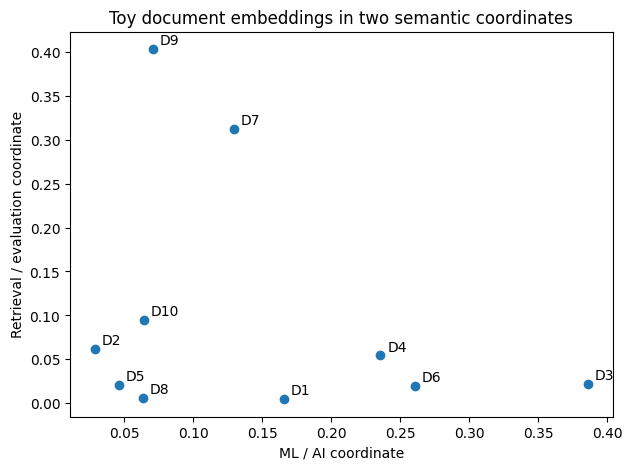

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
axis_x = semantic_axes.index("ml_ai")
axis_y = semantic_axes.index("retrieval_evaluation")
ax.scatter(X_dense[:, axis_x], X_dense[:, axis_y])
for i, d in enumerate(documents):
    ax.annotate(d["id"], (X_dense[i, axis_x] + 0.005, X_dense[i, axis_y] + 0.005))
ax.set_xlabel("ML / AI coordinate")
ax.set_ylabel("Retrieval / evaluation coordinate")
ax.set_title("Toy document embeddings in two semantic coordinates")
plt.show()

## 7. Sparse versus dense retrieval

Sparse retrieval is strong when exact keywords matter.  Dense retrieval is useful when semantic similarity matters even without exact word overlap.

However, dense retrieval can be risky because similar-looking vectors can hide important distinctions.  RAG systems often use **hybrid retrieval**, combining lexical and dense signals.

In [10]:
comparison_queries = [
    "graduate transfer credits and approval",
    "foundations for artificial intelligence",
    "answer questions using external evidence",
    "ways students can get learning help",
]

for q in comparison_queries:
    q_sparse = vectorize_query_tfidf(q, vocab, idf)
    q_sparse = q_sparse / max(np.linalg.norm(q_sparse), 1e-12)
    sparse = X_tfidf_norm @ q_sparse
    dense = dense_scores_for_query(q)
    print("\n" + "="*80)
    display(show_results(q, sparse, k=3, label="sparse TF-IDF"))
    display(show_results(q, dense, k=3, label="dense toy embedding"))


Query: graduate transfer credits and approval
Retriever: sparse TF-IDF


,rank,score,id,title,text
0,1,0.601317,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."
1,2,0.000000,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."
2,3,0.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...


Query: graduate transfer credits and approval
Retriever: dense toy embedding


,rank,score,id,title,text
0,1,0.959318,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."
1,2,0.499917,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
2,3,0.254677,D5,Word embeddings,Word embeddings represent tokens as vectors. S...



Query: foundations for artificial intelligence
Retriever: sparse TF-IDF


...

,rank,score,id,title,text
0,1,0.985742,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
1,2,0.921170,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
2,3,0.587184,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."



Query: ways students can get learning help
Retriever: sparse TF-IDF


,rank,score,id,title,text
0,1,0.303323,D8,Campus tutoring and support,"Students can use tutoring, office hours, peer ..."
1,2,0.154020,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
2,3,0.103984,D5,Word embeddings,Word embeddings represent tokens as vectors. S...


Query: ways students can get learning help
Retriever: dense toy embedding


,rank,score,id,title,text
0,1,0.818190,D8,Campus tutoring and support,"Students can use tutoring, office hours, peer ..."
1,2,0.722075,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
2,3,0.578259,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."


## 8. Hybrid retrieval

A simple hybrid score is

$$
\operatorname{score}_{hybrid}(q,c_i)
= \alpha\operatorname{score}_{sparse}(q,c_i)
+ (1-\alpha)\operatorname{score}_{dense}(q,c_i),
$$

where $0 \leq \alpha \leq 1$.

The parameter $\alpha$ controls the balance between exact token evidence and semantic evidence.

In [11]:
def minmax_normalize(scores, eps=1e-12):
    lo, hi = float(np.min(scores)), float(np.max(scores))
    return (scores - lo) / max(hi - lo, eps)

def hybrid_scores_for_query(query, alpha=0.5):
    q_sparse = vectorize_query_tfidf(query, vocab, idf)
    q_sparse = q_sparse / max(np.linalg.norm(q_sparse), 1e-12)
    sparse = X_tfidf_norm @ q_sparse
    dense = dense_scores_for_query(query)
    return alpha * minmax_normalize(sparse) + (1 - alpha) * minmax_normalize(dense)

query = "What documents explain search quality metrics?"
for alpha in [0.0, 0.3, 0.7, 1.0]:
    scores = hybrid_scores_for_query(query, alpha=alpha)
    display(show_results(query, scores, k=4, label=f"hybrid alpha={alpha}"))

Query: What documents explain search quality metrics?
Retriever: hybrid alpha=0.0


,rank,score,id,title,text
0,1,1.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
1,2,0.958299,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
2,3,0.486566,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."
3,4,0.474416,D5,Word embeddings,Word embeddings represent tokens as vectors. S...


Query: What documents explain search quality metrics?
Retriever: hybrid alpha=0.3


,rank,score,id,title,text
0,1,1.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
1,2,0.884182,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
2,3,0.492489,D4,Naive Bayes classifier,The Naive Bayes text classifier uses Bayes rul...
3,4,0.340596,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."


Query: What documents explain search quality metrics?
Retriever: hybrid alpha=0.7


,rank,score,id,title,text
0,1,1.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
1,2,0.785359,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
2,3,0.570723,D4,Naive Bayes classifier,The Naive Bayes text classifier uses Bayes rul...
3,4,0.145970,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."


Query: What documents explain search quality metrics?
Retriever: hybrid alpha=1.0


,rank,score,id,title,text
0,1,1.000000,D9,Evaluation of retrieval,Retrieval systems are evaluated using precisio...
1,2,0.711241,D7,Retrieval augmented generation,RAG systems retrieve relevant chunks from an e...
2,3,0.629398,D4,Naive Bayes classifier,The Naive Bayes text classifier uses Bayes rul...
3,4,0.000000,D10,Information theory for language,"Entropy, cross entropy, KL divergence, and per..."


### Exercise 2

For the query below, change $\alpha$ from 0 to 1.  Explain how the top results change.

In [12]:
query = "What background do I need for AI and machine learning?"

# Change this value.
alpha = 0.5

scores = hybrid_scores_for_query(query, alpha=alpha)
show_results(query, scores, k=5, label=f"hybrid alpha={alpha}")

Query: What background do I need for AI and machine learning?
Retriever: hybrid alpha=0.5


,rank,score,id,title,text
0,1,0.978111,D3,Mathematical foundations of AI,Modern artificial intelligence relies on linea...
1,2,0.713989,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
2,3,0.500000,D4,Naive Bayes classifier,The Naive Bayes text classifier uses Bayes rul...
3,4,0.336220,D5,Word embeddings,Word embeddings represent tokens as vectors. S...
4,5,0.289469,D6,Transformer attention,Transformers use self-attention to compute con...


## 9. Reranking

A common production architecture uses two stages:

1. **First-stage retrieval:** quickly retrieve a candidate set.
2. **Reranking:** score the candidates more carefully.

Here we implement a transparent reranker using token overlap, title match, and dense similarity.  In a real system, the reranker may be a cross-encoder neural model that jointly reads the query and document.

In [13]:
def token_overlap_score(query, text):
    q = set(tokenize(query))
    d = set(tokenize(text))
    if not q:
        return 0.0
    return len(q & d) / len(q)

def simple_rerank(query, candidate_indices):
    rows = []
    dense = dense_scores_for_query(query)
    for idx in candidate_indices:
        doc = documents[idx]
        full_text = doc["title"] + " " + doc["text"]
        overlap = token_overlap_score(query, full_text)
        title_overlap = token_overlap_score(query, doc["title"])
        score = 0.45 * dense[idx] + 0.35 * overlap + 0.20 * title_overlap
        rows.append((idx, score, dense[idx], overlap, title_overlap))
    rows.sort(key=lambda x: x[1], reverse=True)
    return rows

query = "How do we measure whether retrieved documents are good?"
first_stage = top_k(hybrid_scores_for_query(query, alpha=0.5), k=7)
reranked = simple_rerank(query, first_stage)

pd.DataFrame([
    {"rank": r+1, "id": documents[idx]["id"], "title": documents[idx]["title"], "rerank_score": score,
     "dense": dense, "overlap": overlap, "title_overlap": title_overlap}
    for r, (idx, score, dense, overlap, title_overlap) in enumerate(reranked)
])

,rank,id,title,rerank_score,dense,overlap,title_overlap
0,1,D7,Retrieval augmented generation,0.463824,0.933498,0.125,0.0
1,2,D9,Evaluation of retrieval,0.441636,0.981412,0.000,0.0
2,3,D10,Information theory for language,0.236665,0.428701,0.125,0.0
3,4,D4,Naive Bayes classifier,0.195809,0.337908,0.125,0.0
4,5,D5,Word embeddings,0.184783,0.410629,0.000,0.0
5,6,D2,Transfer credit policy,0.172998,0.384439,0.000,0.0
6,7,D1,MS Applied Mathematics advising,0.116679,0.259287,0.000,0.0


## 10. Chunking as a mathematical design choice

RAG usually retrieves chunks, not entire books or websites.  Chunking controls the set

$$
C = \{c_1,c_2,\ldots,c_n\}
$$

that the retriever searches over.  If chunks are too short, they may lack context.  If chunks are too long, they may mix unrelated topics and waste prompt space.

We will create a few chunks from a long advising-style page and compare retrieval against the original document collection.

In [14]:
long_page = """
The MS Applied Mathematics program requires careful course planning. Students should discuss prerequisites with an advisor before choosing electives.
Transfer credit requests require a syllabus, transcript, and graduate program approval. Approval is not automatic because courses must match program learning goals.
Students interested in AI should build foundations in linear algebra, probability, optimization, numerical computation, statistical learning, and machine learning.
Students who need help can use office hours, tutoring, peer study groups, library resources, and writing support.
A retrieval augmented generation system should retrieve relevant chunks and provide evidence rather than guessing from memory.
""".strip()

sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", long_page) if s.strip()]
chunks = []
for i, sent in enumerate(sentences, start=1):
    chunks.append({"id": f"C{i}", "title": f"Advising page chunk {i}", "text": sent})

pd.DataFrame(chunks)

,id,title,text
0,C1,Advising page chunk 1,The MS Applied Mathematics program requires ca...
1,C2,Advising page chunk 2,Students should discuss prerequisites with an ...
2,C3,Advising page chunk 3,"Transfer credit requests require a syllabus, t..."
3,C4,Advising page chunk 4,Approval is not automatic because courses must...
4,C5,Advising page chunk 5,Students interested in AI should build foundat...
5,C6,Advising page chunk 6,"Students who need help can use office hours, t..."
6,C7,Advising page chunk 7,A retrieval augmented generation system should...


In [15]:
# Build a chunk-level retriever.
chunk_texts = [c["title"] + " " + c["text"] for c in chunks]
chunk_vocab = build_vocabulary(chunk_texts)
X_chunk_tfidf, chunk_idf = tfidf_matrix(chunk_texts, chunk_vocab)
X_chunk_tfidf_norm = l2_normalize(X_chunk_tfidf)

# Use the same dense embedding function for chunks.
X_chunk_dense = np.vstack([text_embedding(t) for t in chunk_texts])
X_chunk_dense_norm = l2_normalize(X_chunk_dense)

def chunk_hybrid_scores(query, alpha=0.5):
    q_sparse = vectorize_query_tfidf(query, chunk_vocab, chunk_idf)
    q_sparse = q_sparse / max(np.linalg.norm(q_sparse), 1e-12)
    sparse = X_chunk_tfidf_norm @ q_sparse
    q_dense = text_embedding(query)
    q_dense = q_dense / max(np.linalg.norm(q_dense), 1e-12)
    dense = X_chunk_dense_norm @ q_dense
    return alpha * minmax_normalize(sparse) + (1 - alpha) * minmax_normalize(dense)

def show_chunk_results(query, scores, k=3):
    rows = []
    for rank, idx in enumerate(top_k(scores, k), start=1):
        rows.append({
            "rank": rank,
            "score": float(scores[idx]),
            "id": chunks[idx]["id"],
            "text": chunks[idx]["text"]
        })
    return pd.DataFrame(rows)

query = "What is needed for transfer credit approval?"
chunk_scores = chunk_hybrid_scores(query, alpha=0.6)
show_chunk_results(query, chunk_scores, k=4)

,rank,score,id,text
0,1,1.000000,C3,"Transfer credit requests require a syllabus, t..."
1,2,0.486891,C4,Approval is not automatic because courses must...
2,3,0.351172,C2,Students should discuss prerequisites with an ...
3,4,0.340127,C1,The MS Applied Mathematics program requires ca...


## 11. Retrieval evaluation

A retriever should be evaluated, not only inspected.  Suppose a query has a set of relevant documents $R_q$.  If the retriever returns a ranked list $L_k$ of length $k$, then

$$
\operatorname{precision@}k = \frac{|L_k \cap R_q|}{k},
$$

and

$$
\operatorname{recall@}k = \frac{|L_k \cap R_q|}{|R_q|}.
$$

The reciprocal rank is

$$
\frac{1}{\text{rank of the first relevant result}}.
$$

The mean reciprocal rank, or MRR, averages this quantity over queries.

In [16]:
# Relevance judgments for the original document collection.
# These are small and subjective, but they let us compute metrics.
queries = [
    {
        "query": "How do I get transfer credit approved?",
        "relevant": {"D2"}
    },
    {
        "query": "What math foundations support artificial intelligence?",
        "relevant": {"D1", "D3"}
    },
    {
        "query": "How does RAG answer questions using external documents?",
        "relevant": {"D7"}
    },
    {
        "query": "How do we evaluate search quality?",
        "relevant": {"D9"}
    },
    {
        "query": "Where can students get academic support?",
        "relevant": {"D8"}
    },
]

id_to_index = {d["id"]: i for i, d in enumerate(documents)}
index_to_id = {i: d["id"] for i, d in enumerate(documents)}

def ranked_doc_ids(scores):
    return [index_to_id[i] for i in np.argsort(scores)[::-1]]

def precision_at_k(ranked_ids, relevant, k):
    top = ranked_ids[:k]
    return sum(x in relevant for x in top) / k

def recall_at_k(ranked_ids, relevant, k):
    top = ranked_ids[:k]
    return sum(x in relevant for x in top) / max(len(relevant), 1)

def reciprocal_rank(ranked_ids, relevant):
    for rank, doc_id in enumerate(ranked_ids, start=1):
        if doc_id in relevant:
            return 1 / rank
    return 0.0

def dcg_at_k(ranked_ids, relevant, k):
    total = 0.0
    for rank, doc_id in enumerate(ranked_ids[:k], start=1):
        rel = 1.0 if doc_id in relevant else 0.0
        total += rel / math.log2(rank + 1)
    return total

def ndcg_at_k(ranked_ids, relevant, k):
    ideal = dcg_at_k(list(relevant), relevant, min(k, len(relevant)))
    if ideal == 0:
        return 0.0
    return dcg_at_k(ranked_ids, relevant, k) / ideal

def scores_for_method(query, method):
    if method == "sparse":
        q = vectorize_query_tfidf(query, vocab, idf)
        q = q / max(np.linalg.norm(q), 1e-12)
        return X_tfidf_norm @ q
    if method == "dense":
        return dense_scores_for_query(query)
    if method == "hybrid":
        return hybrid_scores_for_query(query, alpha=0.5)
    raise ValueError(method)

def evaluate_method(method, k=3):
    rows = []
    for item in queries:
        q = item["query"]
        relevant = item["relevant"]
        scores = scores_for_method(q, method)
        ranked = ranked_doc_ids(scores)
        rows.append({
            "query": q,
            "top_3": ranked[:3],
            "precision@3": precision_at_k(ranked, relevant, k),
            "recall@3": recall_at_k(ranked, relevant, k),
            "RR": reciprocal_rank(ranked, relevant),
            "nDCG@3": ndcg_at_k(ranked, relevant, k),
        })
    return pd.DataFrame(rows)

all_results = []
for method in ["sparse", "dense", "hybrid"]:
    df = evaluate_method(method, k=3)
    summary = df[["precision@3", "recall@3", "RR", "nDCG@3"]].mean().to_dict()
    summary["method"] = method
    all_results.append(summary)
    print("\n", method.upper())
    display(df)

pd.DataFrame(all_results).set_index("method")


 SPARSE


,query,top_3,precision@3,recall@3,RR,nDCG@3
0,How do I get transfer credit approved?,"[D2, D10, D9]",0.333333,1.0,1.0,1.000000
1,What math foundations support artificial intel...,"[D3, D8, D9]",0.333333,0.5,1.0,0.613147
2,How does RAG answer questions using external d...,"[D7, D9, D4]",0.333333,1.0,1.0,1.000000
3,How do we evaluate search quality?,"[D9, D10, D8]",0.333333,1.0,1.0,1.000000
4,Where can students get academic support?,"[D8, D1, D5]",0.333333,1.0,1.0,1.000000



 DENSE


,query,top_3,precision@3,recall@3,RR,nDCG@3
0,How do I get transfer credit approved?,"[D2, D1, D5]",0.333333,1.0,1.000,1.000000
1,What math foundations support artificial intel...,"[D3, D4, D1]",0.666667,1.0,1.000,0.919721
2,How does RAG answer questions using external d...,"[D7, D9, D4]",0.333333,1.0,1.000,1.000000
3,How do we evaluate search quality?,"[D1, D5, D4]",0.000000,0.0,0.125,0.000000
4,Where can students get academic support?,"[D8, D2, D1]",0.333333,1.0,1.000,1.000000



 HYBRID


,query,top_3,precision@3,recall@3,RR,nDCG@3
0,How do I get transfer credit approved?,"[D2, D1, D5]",0.333333,1.0,1.0,1.000000
1,What math foundations support artificial intel...,"[D3, D4, D8]",0.333333,0.5,1.0,0.613147
2,How does RAG answer questions using external d...,"[D7, D9, D4]",0.333333,1.0,1.0,1.000000
3,How do we evaluate search quality?,"[D9, D1, D5]",0.333333,1.0,1.0,1.000000
4,Where can students get academic support?,"[D8, D1, D2]",0.333333,1.0,1.0,1.000000


,precision@3,recall@3,RR,nDCG@3
method,,,,
sparse,0.333333,0.9,1.000,0.922629
dense,0.333333,0.8,0.825,0.783944
hybrid,0.333333,0.9,1.000,0.922629


### Exercise 3

Add a new query and a relevant document set.  Recompute the metric table.  How sensitive are the averages to one extra query?

In [17]:
# Example: uncomment and modify.
# queries.append({
#     "query": "What is perplexity in language modeling?",
#     "relevant": {"D10"}
# })
# pd.DataFrame([evaluate_method(m, k=3)[["precision@3", "recall@3", "RR", "nDCG@3"]].mean().to_dict() | {"method": m}
#               for m in ["sparse", "dense", "hybrid"]]).set_index("method")

## 12. A transparent RAG-style answer builder

A RAG system usually follows this pattern:

1. receive a query;
2. retrieve relevant chunks;
3. construct a context window;
4. generate an answer grounded in that context;
5. provide citations or evidence links.

Here we implement a transparent toy version.  Instead of a language model, we select the most relevant sentences from the retrieved context.  This keeps the system auditable.

In [18]:
def split_sentences(text):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def retrieve_documents(query, k=3, alpha=0.5):
    scores = hybrid_scores_for_query(query, alpha=alpha)
    idxs = top_k(scores, k=k)
    return [(documents[i], float(scores[i])) for i in idxs]

def sentence_score(query, sentence):
    # Transparent sentence scoring: query-token overlap plus dense alignment.
    overlap = token_overlap_score(query, sentence)
    q = text_embedding(query)
    s = text_embedding(sentence)
    if np.linalg.norm(q) == 0 or np.linalg.norm(s) == 0:
        dense = 0.0
    else:
        dense = float(q @ s / (np.linalg.norm(q) * np.linalg.norm(s)))
    return 0.55 * overlap + 0.45 * dense

def build_extractive_answer(query, retrieved, max_sentences=3):
    candidates = []
    for doc, doc_score in retrieved:
        for sent in split_sentences(doc["text"]):
            candidates.append({
                "sentence": sent,
                "doc_id": doc["id"],
                "title": doc["title"],
                "score": sentence_score(query, sent),
                "doc_score": doc_score,
            })
    candidates.sort(key=lambda x: (x["score"], x["doc_score"]), reverse=True)
    selected = candidates[:max_sentences]
    answer = " ".join([f"{c['sentence']} [{c['doc_id']}]" for c in selected])
    sources = pd.DataFrame([{ "id": c["doc_id"], "title": c["title"], "sentence_score": c["score"] } for c in selected])
    return answer, sources

def toy_rag(query, k=3, alpha=0.5):
    retrieved = retrieve_documents(query, k=k, alpha=alpha)
    answer, sources = build_extractive_answer(query, retrieved)
    retrieved_table = pd.DataFrame([
        {"rank": i+1, "score": score, "id": doc["id"], "title": doc["title"], "text": doc["text"]}
        for i, (doc, score) in enumerate(retrieved)
    ])
    return answer, retrieved_table, sources

query = "How do transfer credits get approved?"
answer, retrieved_table, sources = toy_rag(query, k=4, alpha=0.6)
print("Question:", query)
print("\nToy RAG answer:")
print(answer)
print("\nRetrieved context:")
display(retrieved_table)
print("\nSelected source sentences:")
display(sources)

Question: How do transfer credits get approved?

Toy RAG answer:
Transfer credits require official syllabi, transcript evidence, and approval by the graduate program director. [D2] Students in the MS Applied Mathematics program should plan courses with an academic advisor. [D1] Courses must be graduate level and substantially similar to the required curriculum. [D2]

Retrieved context:


,rank,score,id,title,text
0,1,1.000000,D2,Transfer credit policy,"Transfer credits require official syllabi, tra..."
1,2,0.204243,D1,MS Applied Mathematics advising,Students in the MS Applied Mathematics program...
2,3,0.095934,D5,Word embeddings,Word embeddings represent tokens as vectors. S...
3,4,0.056886,D8,Campus tutoring and support,"Students can use tutoring, office hours, peer ..."



Selected source sentences:


,id,title,sentence_score
0,D2,Transfer credit policy,0.610210
1,D1,MS Applied Mathematics advising,0.417888
2,D2,Transfer credit policy,0.370871


## 13. Diagnosing RAG failure modes

A RAG system can fail at different stages:

| Stage | Failure mode | Example |
|---|---|---|
| retrieval | relevant evidence is not retrieved | the answer is absent from top-$k$ |
| ranking | evidence is retrieved but ranked too low | relevant chunk appears below irrelevant chunks |
| context construction | good chunks are included but too much irrelevant context is added | answer is buried |
| generation | model ignores context or overgeneralizes | hallucinated answer |
| citation | answer is correct but citation points to wrong source | unverifiable output |

The most important debugging rule is to separate these stages.  Do not blame the generator if the retriever never supplied the evidence.

In [19]:
diagnostic_queries = [
    "Who approves transfer credits?",
    "Can a RAG system answer from private documents?",
    "What is the cafeteria menu today?"  # intentionally out of collection
]

for q in diagnostic_queries:
    answer, retrieved_table, sources = toy_rag(q, k=3, alpha=0.5)
    print("\n" + "="*90)
    print("Question:", q)
    print("Answer:", answer)
    display(retrieved_table[["rank", "score", "id", "title"]])


Question: Who approves transfer credits?
Answer: Transfer credits require official syllabi, transcript evidence, and approval by the graduate program director. [D2] Students in the MS Applied Mathematics program should plan courses with an academic advisor. [D1] Courses must be graduate level and substantially similar to the required curriculum. [D2]


,rank,score,id,title
0,1,1.000000,D2,Transfer credit policy
1,2,0.266442,D1,MS Applied Mathematics advising
2,3,0.128472,D5,Word embeddings



Question: Can a RAG system answer from private documents?
Answer: Retrieval helps answer questions about documents not memorized during training. [D7] RAG systems retrieve relevant chunks from an external collection and pass them as context to a language model. [D7] It estimates class priors and token likelihoods from labeled documents. [D4]


,rank,score,id,title
0,1,1.000000,D7,Retrieval augmented generation
1,2,0.488322,D9,Evaluation of retrieval
2,3,0.322329,D4,Naive Bayes classifier



Question: What is the cafeteria menu today?
Answer: Similar words tend to have nearby vectors, and vector arithmetic can reveal semantic directions. [D5] The Naive Bayes text classifier uses Bayes rule with conditional independence assumptions. [D4] Core courses include applied linear algebra, probability, stochastic processes, optimization, and machine learning. [D1]


,rank,score,id,title
0,1,0.500000,D5,Word embeddings
1,2,0.485447,D1,MS Applied Mathematics advising
2,3,0.469575,D4,Naive Bayes classifier


### Exercise 4

For the cafeteria query above, the system still returns something.  Explain why this happens mathematically.  Then propose a rejection rule such as:

$$
\max_i \operatorname{score}(q,c_i) < \tau.
$$

What should the threshold $\tau$ be for this toy system?

In [20]:
# Inspect maximum hybrid scores for in-domain and out-of-domain queries.
probe_queries = [
    "How do transfer credits get approved?",
    "How does RAG retrieve evidence?",
    "What is the cafeteria menu today?",
    "Who won the baseball game yesterday?",
]

rows = []
for q in probe_queries:
    scores = hybrid_scores_for_query(q, alpha=0.5)
    rows.append({"query": q, "max_score": float(scores.max()), "top_doc": documents[int(scores.argmax())]["id"]})

pd.DataFrame(rows)

,query,max_score,top_doc
0,How do transfer credits get approved?,1.0,D2
1,How does RAG retrieve evidence?,1.0,D7
2,What is the cafeteria menu today?,0.5,D5
3,Who won the baseball game yesterday?,0.5,D1


## 14. Approximate nearest-neighbor search: conceptual simulation

For a collection with millions of vectors, exact search by $Xz$ can be expensive.  Approximate nearest-neighbor methods trade exactness for speed.

This lab does not implement a production ANN index.  Instead, we simulate the idea of partitioning: group documents by a coarse semantic coordinate, search only the most promising group, and compare with exact search.

In [21]:
# A very small partitioning scheme: assign each document to its largest semantic coordinate.
cluster_labels = [semantic_axes[int(np.argmax(v))] for v in X_dense]
partition_table = pd.DataFrame({
    "id": [d["id"] for d in documents],
    "title": [d["title"] for d in documents],
    "coarse_partition": cluster_labels,
})
partition_table

,id,title,coarse_partition
0,D1,MS Applied Mathematics advising,probability_math
1,D2,Transfer credit policy,advising_admin
2,D3,Mathematical foundations of AI,probability_math
3,D4,Naive Bayes classifier,ml_ai
4,D5,Word embeddings,probability_math
5,D6,Transformer attention,sequence_models
6,D7,Retrieval augmented generation,retrieval_evaluation
7,D8,Campus tutoring and support,student_support
8,D9,Evaluation of retrieval,retrieval_evaluation
9,D10,Information theory for language,probability_math


In [22]:
def approximate_dense_search(query, k=3):
    q = text_embedding(query)
    partition = semantic_axes[int(np.argmax(q))] if np.linalg.norm(q) > 0 else semantic_axes[0]
    candidate_indices = [i for i, label in enumerate(cluster_labels) if label == partition]
    if not candidate_indices:
        candidate_indices = list(range(len(documents)))
    scores = dense_scores_for_query(query)
    ranked_candidates = sorted(candidate_indices, key=lambda i: scores[i], reverse=True)[:k]
    exact = top_k(scores, k=k)
    return partition, ranked_candidates, exact, scores

query = "How can students find tutoring and writing support?"
partition, approx, exact, scores = approximate_dense_search(query, k=3)
print("Query partition:", partition)
print("Approximate results:", [documents[i]["id"] for i in approx])
print("Exact dense results:", [documents[i]["id"] for i in exact])

Query partition: student_support
Approximate results: ['D8']
Exact dense results: ['D8', 'D1', 'D2']


### Discussion

Approximate search can miss relevant documents if the coarse partition is wrong.  This is a key mathematical tradeoff:

$$
\text{speed} \quad \text{versus} \quad \text{recall}.
$$

High-quality ANN systems use more sophisticated partitions, graph search, quantization, or combinations of these ideas.

## 15. Mini-project: build and audit a small RAG retriever

Choose one of the following mini-projects.

### Option A: course advising RAG

Create 5 to 8 short policy documents for a fictional program.  Build a hybrid retriever and answer these questions:

1. What are the required courses?
2. How are transfer credits approved?
3. What support resources are available?
4. What electives are recommended for AI?

Report precision@$3$ and recall@$3$ for at least four queries.

### Option B: mathematical NLP textbook RAG

Create 5 to 8 chunks summarizing earlier chapters of this book: tokenization, TF-IDF, Naive Bayes, embeddings, attention, transformers, and autoregressive models.  Build a retriever that answers conceptual questions about the book.

### Option C: failure-mode audit

Create at least three adversarial or out-of-domain queries.  For each one, identify whether the main problem is retrieval failure, ranking failure, context overload, generation failure, or citation failure.

## 16. AI-assisted learning prompts

Use an AI assistant only after you have run the code yourself.  Good prompts include:

1. "Explain why cosine similarity is unchanged by multiplying a vector by a positive scalar."
2. "Given this top-$k$ retrieval list and this relevance set, compute precision@$k$, recall@$k$, MRR, and nDCG by hand."
3. "Help me design three queries that distinguish sparse lexical retrieval from dense semantic retrieval."
4. "Audit this RAG answer: which sentence is supported by which source, and where might hallucination enter?"
5. "Explain the difference between retrieval failure and generation failure in a RAG pipeline."

## 17. Summary

In this lab, you built a complete transparent retrieval pipeline:

- a sparse TF-IDF retriever;
- a dense toy embedding retriever;
- a hybrid retriever;
- a reranker;
- a chunk-level retriever;
- retrieval metrics;
- an extractive RAG-style answer builder;
- simple diagnostics for failure modes and out-of-domain queries.

The central mathematical idea is that RAG turns part of language modeling into a geometric search problem over vectors.  Better generation cannot fix missing evidence; retrieval quality, chunking, ranking, and evaluation are fundamental parts of the system.